In [1]:
# run in terminal to mount the network drive in WSL
# sudo mount -t drvfs '\\data03\pi-vannoort' /mnt/data03 -o username=noort

In [2]:
import os
from pathlib import Path
import pandas as pd
import pysam
from icecream import ic
import numpy as np
from tqdm import tqdm

import sys
from pathlib import Path
# Add nuctool directory to path for imports
nuctool_path = Path.cwd().parent / 'nuctool'
if str(nuctool_path) not in sys.path:
    sys.path.insert(0, str(nuctool_path))
from Plotter import Plotter

In [3]:
filename = Path(r"/mnt/data03/Noort/Data/Daxinger/dnmt.bam")
filename = Path(r"/home/mvenrooij/NucTool/nuctool/methylation data/gal_locus.Raf_6mA.bam")

if not filename.with_suffix(".bai").exists() and filename.exists():
    pysam.index(filename.as_posix())

bam = pysam.AlignmentFile(filename, "rb")

In [4]:
def extract_locus(locus_txt):
    locus_txt = locus_txt.replace(',', '')
    parts = locus_txt.split(':')
    chrom = parts[0]
    start, end = map(int, parts[1].split('-'))
    return (chrom, start, end)

locus = extract_locus("chrII:278,635-278,757")
locus = extract_locus("chrII:272,114-280,662")
locus = extract_locus("chrII:275,320-277,456")
locus = extract_locus("chrII:273,000-283,000")

In [5]:
for read in bam.fetch(*locus):
    print("Read:", read.query_name)

    mm = read.get_tag("MM") if read.has_tag("MM") else None
    ml = read.get_tag("ML") if read.has_tag("ML") else None
    
    print("MM:", str(mm)[:100])
    if ml:
        print("ML (first 20):", list(ml[:20]))
    break

Read: m84219_240203_140226_s3/198967501/ccs
MM: C+m,0,1,4,17,3,0,3,1,1,13,1,11,19,0,9,7,9,2,5,1,0,1,12,7,9,16,16,4,12,0,9,1,2,8,9,2,14,9,4,5,14,1,0,
ML (first 20): [120, 51, 97, 98, 10, 31, 47, 74, 14, 8, 41, 189, 99, 138, 77, 19, 102, 167, 35, 9]


In [6]:
def get_modification_probabilities(read):
    if not read.has_tag("MM"):
        return {}

    mm = read.get_tag("MM")
    ml = read.get_tag("ML") if read.has_tag("ML") else []

    mods = {}
    ml_idx = 0
    seq = read.query_sequence
    is_reverse = read.is_reverse

    aligned_pairs = read.get_aligned_pairs()
    q_to_r = {q: r for q, r in aligned_pairs if q is not None}

    for section in mm.split(';'):
        if not section:
            continue
        header, *counts = section.split(',')
        if '+' not in header and '-' not in header:
            continue

        target_base = header[0]

        # On forward strand, we want A modifications (A in stored seq)
        # On reverse strand, we want A modifications too but pysam stores
        # them as T in the sequence with T in the MM tag header
        if is_reverse and target_base != 'T':
            ml_idx += len(counts)
            continue
        if not is_reverse and target_base != 'A':
            ml_idx += len(counts)
            continue

        target_indices = [i for i, b in enumerate(seq) if b == target_base]

        if is_reverse:
            target_indices = target_indices[::-1]

        current_mod_probs = {}
        target_idx = 0

        for c in counts:
            try:
                skip = int(c)
            except ValueError:
                continue

            target_idx += skip
            if target_idx < len(target_indices):
                q_pos = target_indices[target_idx]
                r_pos = q_to_r.get(q_pos)
                if r_pos is not None:
                    prob = ml[ml_idx] / 255.0 if ml_idx < len(ml) else 1.0
                    current_mod_probs[r_pos] = prob

            ml_idx += 1
            target_idx += 1

        mods[header] = current_mod_probs

    return mods

In [7]:

def reverse_complement(seq):
    COMPLEMENT = str.maketrans('ACGTacgt', 'TGCAtgca')
    return seq.translate(COMPLEMENT)

def get_read_methylation_string(read, chrom, start, end, threshold=0.5):
    mods = get_modification_probabilities(read)
    active_mod_dicts = list(mods.values())

    aligned_pairs = read.get_aligned_pairs()
    seq = read.query_sequence
    locus_length = end - start
    res = ["-"] * locus_length

    COMPLEMENT = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C', 'N': 'N'}
    
    expected_base = 't' if read.is_reverse else 'a'  # in stored sequence coords

    for q_pos, r_pos in aligned_pairs:
        if r_pos is not None and start <= r_pos < end:
            idx = r_pos - start
            if q_pos is not None:
                base = seq[q_pos]
                if read.is_reverse:
                    base = COMPLEMENT.get(base, base)  # show reference-strand base
                base = base.lower()

                if seq[q_pos].lower() == expected_base:  # check in stored seq coords
                    max_prob = 0
                    for m_dict in active_mod_dicts:
                        max_prob = max(max_prob, m_dict.get(r_pos, 0))
                    if max_prob > threshold:
                        base = base.upper()

                res[idx] = base

    result = "".join(res)

    if read.is_reverse:
        return reverse_complement(result)
    else:   
        return result

In [8]:
def get_methylation_distribution(bam, locus, n_reads=200, plot=False):
    chrom, start, end = locus
    locus_length = end - start

    # --- Consensus reference sequence ---
    reference_sequence_lookup = ["?"] * locus_length
    for read in bam.fetch(*locus):
        seq = read.query_sequence
        for q_pos, r_pos in read.get_aligned_pairs():
            if r_pos is not None and start <= r_pos < end and q_pos is not None:
                reference_sequence_lookup[r_pos - start] = seq[q_pos].lower()
        if "?" not in reference_sequence_lookup:
            break

    # --- Methylation accumulation ---
    meth_loc = np.zeros(locus_length)
    cov_loc  = np.zeros(locus_length)

    reads_list = list(bam.fetch(*locus))
    n_to_process = min(n_reads, len(reads_list))

    for read in tqdm(reads_list[:n_to_process]):
        meth_string = get_read_methylation_string(read, *locus)
        for idx, char in enumerate(meth_string):
            if char != '-':
                cov_loc[idx] += 1
                if char.isupper():
                    meth_loc[idx] += 1

    f_meth_loc = meth_loc / np.where(cov_loc > 0, cov_loc, 1)

    if plot:
        x_coords = np.arange(start, end)
        plotter = Plotter(fig_size=(15, 4))
        plotter.new(nrows=1, ncols=1)
        ax = plotter.axes
        ax.bar(x_coords, f_meth_loc, color='skyblue', width=1.0, label='Methylation')
        ax.set_ylabel("Loc Meth")
        ax.set_ylim(0, 1.1)
        ax.set_xlim(start, end)
        if locus_length < 150:
            ax.set_xticks(x_coords)
            ax.set_xticklabels(reference_sequence_lookup, fontfamily='monospace', fontsize=7)
        plotter.caption(f"Methylation sites for locus:{chrom}:{start}-{end}")

    return f_meth_loc, reference_sequence_lookup


In [ ]:
n_reads = 500

bam = pysam.AlignmentFile(filename, "rb")
chrom, start, end = locus

test_string = "A" *((end-start)//2) + "t" * ((end-start)//2)

f_meth_loc, reference_seq = get_methylation_distribution(bam, locus, 200, True)


 10%|█         | 20/200 [00:00<00:01, 99.09it/s]

Locus: chrII:273000-283000


100%|██████████| 500/500 [00:02<00:00, 173.22it/s]


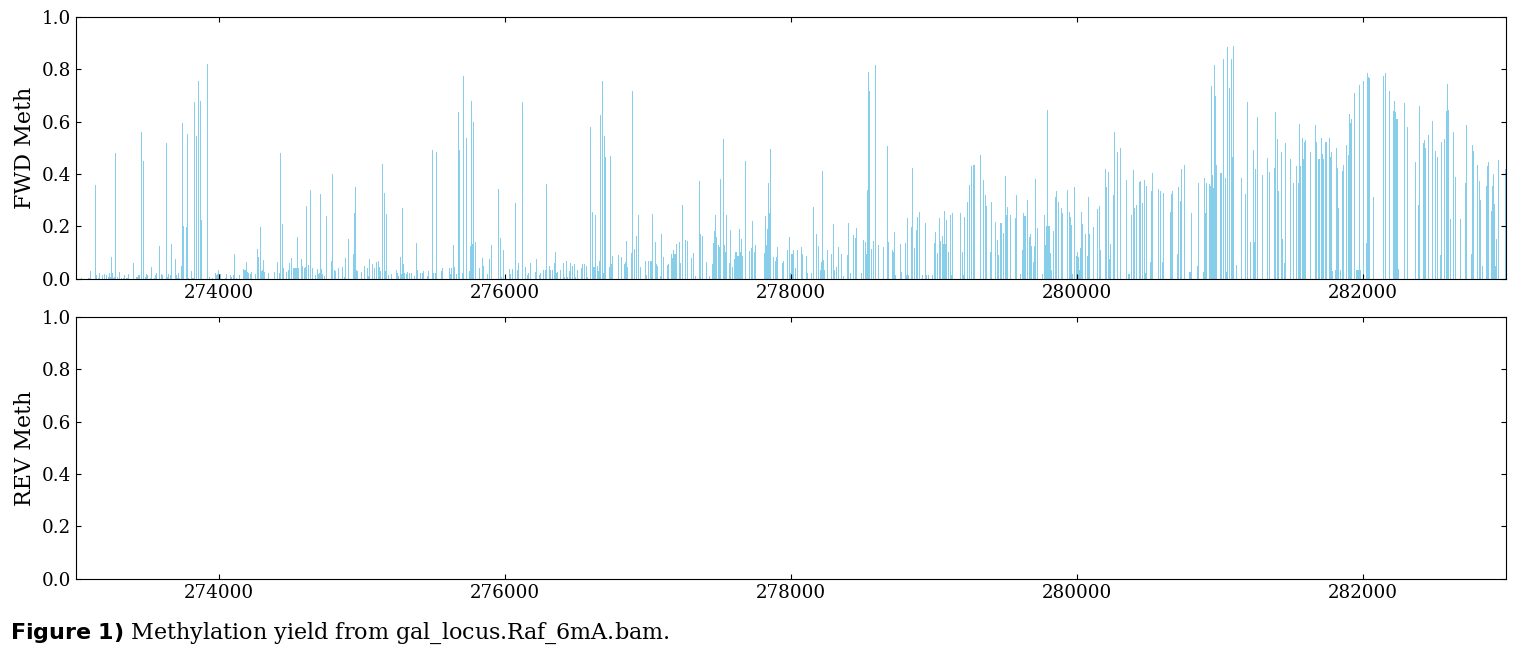

In [ ]:
n_reads = 500 

bam = pysam.AlignmentFile(filename, "rb")
chrom, start, end = locus



# Get a stable consensus sequence
reference_sequence_lookup = ["?"] * (end - start)
for read in bam.fetch(*locus):
    aligned_pairs = read.get_aligned_pairs()
    seq = read.query_sequence
    for q_pos, r_pos in aligned_pairs:
        if r_pos is not None and start <= r_pos < end and q_pos is not None:
            reference_sequence_lookup[r_pos - start] = seq[q_pos].lower()
    if "?" not in reference_sequence_lookup:
        break

meth_fwd = np.zeros(end - start)
meth_rev = np.zeros(end - start)
cov_fwd = np.zeros(end - start)
cov_rev = np.zeros(end - start)

print(f"Locus: {chrom}:{start}-{end}")
# Use list() or similar to identify total reads if possible, otherwise stick to fetch
reads_list = list(bam.fetch(*locus))
total_available = len(reads_list)
n_to_process = min(n_reads, total_available)

for i in tqdm(range(n_to_process)):
    read = reads_list[i]
    meth_string = get_read_methylation_string(read, *locus)
    # meth_string = "A" *((end - start)//2) + "T" * ((end-start)//2)# Placeholder for testing
    # if i < 50:
    #     if read.is_reverse:
    #         meth_string = "At"*((end - start)//2)
    #         print(meth_string[:300])
    #     else:
    #         meth_string = ("Ta"*((end - start)//2))[::-1]
    #         print(meth_string[:300])
    for idx, char in enumerate(meth_string):
        if char != '-':
            if read.is_reverse:
                if char == 'T': 
                    meth_fwd[-idx-1] += 1
                    cov_fwd[-idx-1] += 1
                elif char == 'A':
                    meth_rev[idx] += 1
                    cov_rev[idx] +=1
                else:
                    cov_rev[idx] += 1
            else:
                if char == 'T':
                    meth_rev[-idx-1] += 1
                    cov_rev[-idx-1] += 1
                elif char == 'A':
                    meth_fwd[idx] += 1
                    cov_fwd[idx] += 1
                else:
                    cov_fwd[idx] += 1
            #     if char == 'T': 
            #         meth_fwd[-idx-1] += 1
            #         cov_fwd[-idx-1] += 1
            #     elif char == 'A':
            #         meth_rev[idx] += 1
            #         cov_rev[idx] += 1
            # else:
            #     if char == 'T':
            #         meth_rev[-idx-1] += 1
            #         cov_rev[-idx-1] += 1
            #     elif char == 'A':
            #         meth_fwd[idx] += 1
            #         cov_fwd[idx] += 1

# Compute fractions
meth_rev = meth_rev[::-1]
cov_rev = cov_rev[::-1]
f_meth_fwd = meth_fwd / np.where(cov_fwd > 0, cov_fwd, 1)
f_meth_rev = meth_rev / np.where(cov_rev > 0, cov_rev, 1)

# Plotting
plotter = Plotter(fig_size=(15, 6))
plotter.new(nrows=2, ncols=1)
ax1, ax2 = plotter.axes

x_coords = np.arange(start, end)
ax1.bar(x_coords, f_meth_fwd, color='skyblue', label='Forward Reads', width=1.0)
ax1.set_ylabel("FWD Meth")
ax1.set_ylim(0, 1)
ax1.set_xlim(start, end)

ax2.bar(x_coords, f_meth_rev, color='salmon', label='Reverse Reads', width=1.0)
if len(x_coords) < 200:
    ax1.set_xticks(x_coords)
    ax1.set_xticklabels(reference_sequence_lookup, fontfamily='monospace', fontsize=7)
    ax2.set_xticks(x_coords)
    ax2.set_xticklabels(reference_sequence_lookup[::-1], fontfamily='monospace', fontsize=7)

ax2.set_ylabel("REV Meth")
ax2.set_ylim(0, 1)
ax2.set_xlim(start, end)

plotter.caption(f"Methylation yield from {filename.name}.")

In [ ]:

# Get a stable consensus sequence
reference_sequence_lookup = ["?"] * (end - start)
for read in bam.fetch(*locus):
    aligned_pairs = read.get_aligned_pairs()
    seq = read.query_sequence
    for q_pos, r_pos in aligned_pairs:
        if r_pos is not None and start <= r_pos < end and q_pos is not None:
            reference_sequence_lookup[r_pos - start] = seq[q_pos].lower()
    if "?" not in reference_sequence_lookup:
        break

reference_sequence_lookup = reference_sequence_lookup

reverse_string = reverse_complement("".join(reference_sequence_lookup))

meth_loc = np.zeros(end - start)
meth_rev = np.zeros(end - start)
meth_fwd = np.zeros(end - start)
cov_loc = np.zeros(end - start)
cov_rev = np.zeros(end - start)
cov_fwd = np.zeros(end - start)

print(f"Locus: {chrom}:{start}-{end}")
# Use list() or similar to identify total reads if possible, otherwise stick to fetch
reads_list = list(bam.fetch(*locus))
total_available = len(reads_list)
n_to_process = min(1000, total_available)

n_rev = 0
n_fwd = 0

for i in tqdm(range(n_to_process)):
    read = reads_list[i]
    meth_string = get_read_methylation_string(read, *locus)
    # meth_string = test_string# Placeholder for testing
    if read.is_reverse:
        n_rev += 1
    else:
        n_fwd += 1
    for idx, char in enumerate(meth_string):
        if char != '-':
            if read.is_reverse:
                cov_rev[idx]+=1
                # cov_fwd[-idx-1] += 1
                if char.isupper():
                    meth_rev[idx]+=1
                    # meth_fwd[-idx-1] += 1

            else:
                cov_fwd[idx] += 1
                # cov_rev[-idx-1] += 1
                if char.isupper():
                    meth_fwd[idx] += 1
                    # meth_rev[-idx-1] += 1
cov_rev = np.where(meth_rev!=0, cov_rev, 0)
cov_fwd = np.where(meth_fwd!=0, cov_fwd, 0)

print(n_rev, n_fwd)
#adjust for difference in amount of forward and reverse sequences
fwd_rev_ratio = n_fwd/n_rev
meth_loc += meth_loc[::-1]
f_meth_loc = meth_loc / np.where(cov_loc > 0, cov_loc, 1)



# meth_rev = meth_rev[::-1]
# cov_rev = cov_rev[::-1]

# meth_rev = meth_rev/n_rev
# meth_fwd = meth_fwd/n_fwd

# cov_rev = cov_rev/n_rev
# cov_fwd = cov_fwd/n_fwd

# Normalize each strand by its read count
f_meth_fwd = meth_fwd / np.where(cov_fwd > 0, cov_fwd, 1)
f_meth_rev = meth_rev / np.where(cov_rev > 0, cov_rev, 1)

# Then average the two strands equally
f_meth_sec = (f_meth_fwd + f_meth_rev)

# Plotting
print("Reverse count = ", n_rev, "\nForward count = ", n_fwd)
print("Rev Meth max = ", np.max(meth_rev), "\nFwd Meth max = ", np.max(meth_fwd))
print("Rev Meth = ", meth_rev, "\nFwd Meth = ", meth_fwd[1700:1900])
print("Rev Cov = ", cov_rev, "\nFwd Cov = ", cov_fwd[1700:1900])
print(f_meth_rev[1700:1900],"\n", f_meth_fwd)
# f_meth_sec


Locus: chrII:273000-283000


100%|██████████| 1000/1000 [00:06<00:00, 162.61it/s]

494 506
Reverse count =  494 
Forward count =  506
Rev Meth max =  494.0 
Fwd Meth max =  437.0
Rev Meth =  [ 0. 31. 37. ...  0.  0.  0.] 
Fwd Meth =  [  0.   0.   0.   0.   1.   2.   4.   0.   0.   0. 131.   0.   0.   0.
   0. 162.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  73.
   0.   0.  54.   0.   0.   0.   0.   0.   0.   0.   0.   0.   9.   0.
   0.   0.   0.   0.   0.   2.   7.   0.   0.   0. 109.   0.   0.   0.
  78. 107.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  27.   8.  71.   0.   0. 127.   0.   0. 119. 118.   0.   0.   0.   0.
   0.   0.  23.  14.  73.   0.   0.   0.   0.   0. 207.   0. 213.   0.
   0.   0.   0.   0.   0. 205.   0.   0. 148.   0.   0.   0.  24.  81.
   0.  41. 135.   0.  33.  97.   0.  12.  52.   0.   6.  17. 100.   0.
   0. 105.   0.   0.   0.  32.   0.   0.   0.   0.   0.   0. 173.   0.
   0. 149.   0.   0. 143.   0.   0.   0.   0.   0.   0. 115.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0. 114.   0.   0.   0.   

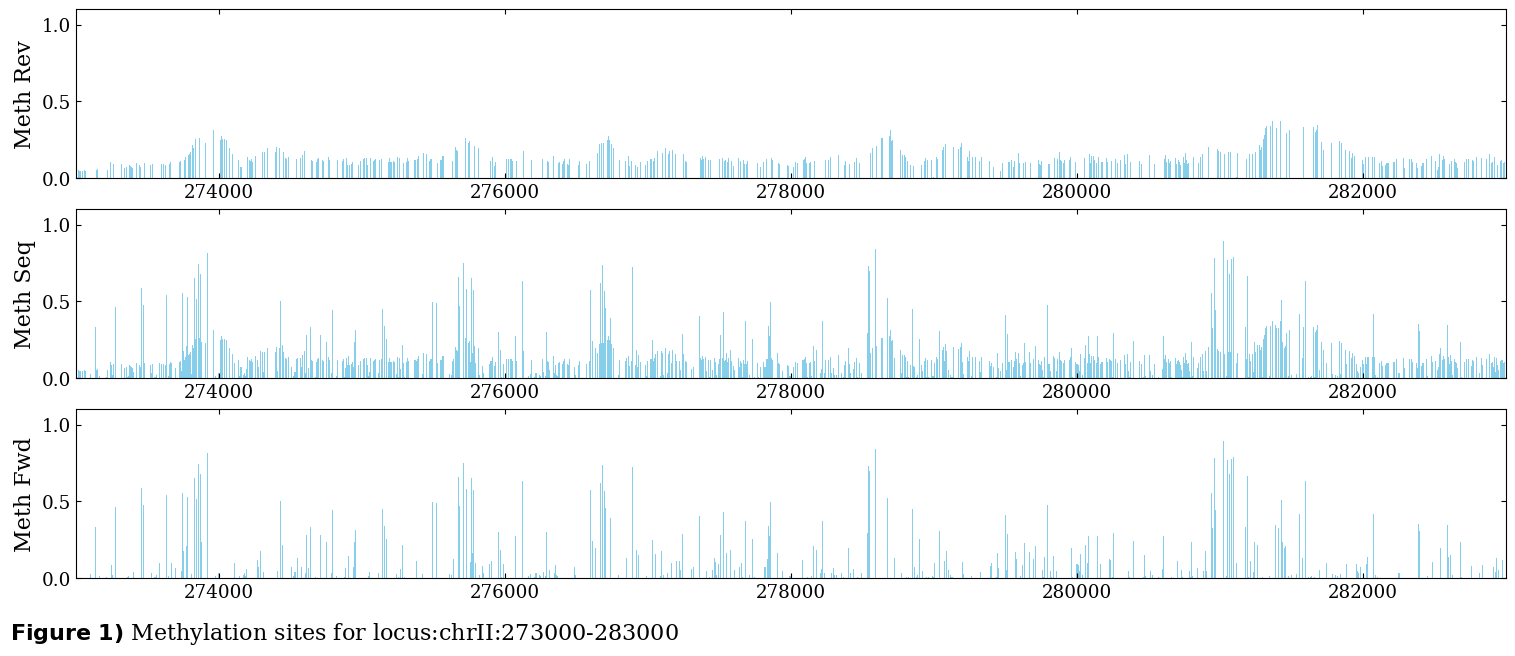

In [ ]:
plotter = Plotter(fig_size=(15, 6))
plotter.new(nrows=3, ncols=1)
ax1, ax2, ax3  = plotter.axes

x_coords = np.arange(start, end)
ax1.bar(x_coords, f_meth_rev, color='skyblue', label='Methylation', width=1.0)
ax1.set_ylabel("Meth Rev")
ax1.set_ylim(0, 1.1)
ax1.set_xlim(start, end)
ax2.bar(x_coords, f_meth_sec, color='skyblue', label='Methylation', width=1.0)
ax2.set_ylabel("Meth Seq")
ax2.set_ylim(0, 1.1)
ax2.set_xlim(start, end)
ax3.bar(x_coords, f_meth_fwd, color='skyblue', label='Methylation', width=1.0)
ax3.set_ylabel("Meth Fwd")
ax3.set_ylim(0, 1.1)
ax3.set_xlim(start, end)
# ax4.bar(x_coords, f_meth_rev, color='skyblue', label='Methylation', width=1.0)
# ax4.set_ylabel("Loc Meth")
# ax4.set_ylim(0, 1.1)
# ax4.set_xlim(start, end)
if len(x_coords) < 150:
    ax1.set_xticks(x_coords)
    ax1.set_xticklabels(reference_sequence_lookup, fontfamily='monospace', fontsize=7)
plotter.caption(f"Methylation sites for locus:{chrom}:{start}-{end}")


In [ ]:
def get_read_methylation_positions(read, locus, threshold=0.5, plot=False):
    chrom, start, end = locus
    mods = get_modification_probabilities(read)
    active_mod_dicts = list(mods.values())

    positions = []

    for q_pos, r_pos in read.get_aligned_pairs():
        if r_pos is None or not (start <= r_pos < end) or q_pos is None:
            continue
        max_prob = max((m.get(r_pos, 0) for m in active_mod_dicts), default=0)
        if max_prob > threshold:
            positions.append(r_pos)

    if plot:
        plotter = Plotter(fig_size=(15, 2))
        plotter.new(nrows=1, ncols=1)
        ax = plotter.axes

        read_start = max(read.reference_start, start)
        read_end   = min(read.reference_end,   end)
        ax.plot([read_start, read_end], [0, 0], color='lightgray', lw=1, zorder=1)
        ax.scatter(positions, [0] * len(positions),
                   color='steelblue', s=10, zorder=2, linewidths=0)

        ax.set_xlim(start, end)
        ax.set_yticks([])
        ax.set_xlabel("Genomic position")
        plotter.caption(f"Methylation positions for read {read.query_name} — locus:{chrom}:{start}-{end}")

    return positions


In [ ]:
length_limit = [40, 200]
def get_nucleosome_occupancy_meth(read, locus, length_limit, plot = False):
    chrom, start, end = locus
    lower_limit, upper_limit = length_limit
    positions = get_read_methylation_positions(read, locus)

    length_unmethylated = np.diff(positions, prepend=start)
    
    occupancy = np.zeros(end-start)

    for begin, length in zip(positions, length_unmethylated):
        local_begin = begin - start
        if lower_limit <= length <= upper_limit:
            occupancy[local_begin:local_begin+length] = 1
    
    


    if plot:
        plotter = Plotter(fig_size=(15, 2))
        plotter.new(nrows = 1, ncols = 1)
        ax = plotter.axes

        x_coords = np.arange(start, end)

        ax.plot(x_coords, occupancy)
        ax.set_xlim(start, end)
        ax.set_yticks([])
        ax.set_xlabel("Genomic position")
        plotter.caption(f"Methylation positions for read {read.query_name} — locus:{chrom}:{start}-{end}")
    
    return occupancy


False
atttatctaatctcacaataaaactttgtgtttgtagcgggatcactgtatttatacatttcaccgattctgagcgaatcacaggtgagaaatttggattcgaaataaacctaaaaaaactatccaataaggcttccAtAggcttcgtatttcccgAccAttccaattggaaaaattgagcgctgtcttccatgatcttagataaagccttaatacttggctcatttccatttgaggttagctctagcaactggtaaagcatttgaagaccagttggatcatctctatgctgcctAtagtaagtggaaaataaagtagtaataacgatacctgtcacgttcgaaacgAgattattgttcgaattataaaggccatgtataatgtttgatttgacgtatcctaagtcgtggctattgctcttaattaaattgtttccccctagcattgaatttttcaacAgcAtAccggcggtAgctctattgttctgaAgAtcctgtagggAgtagtgttgcttcaatacatcAtcagattcgccttcaattaaaatataacacaaataattgagaaattcaggttgcagctggaagttctccatagcttccattgcgttattacgaatctctggatttggtgacatacagttctgtaaaagAgttgctagttgcaacacatagtcttcggcgggcttccatgtcgatgccatctttattcacttaactactgctaacaattctgaaaaccaaagActgcggaatattctgatatgtattattactattcActgctcttctgcAtaattaatActgAaaagtttttcatacttttaaAcAtAAcctttttttaagcaaaActctAtAAcccggAtcAgaaaActAcgaAaagAgggtaAtaAcAtAggtgcAggAtttccAtcgAtaAcgAcAccgAcaAtgAgccttgctgcaacatccaattaggactaataactatcgtaggaatttctacgtaataaact

(273000.0, 283000.0)

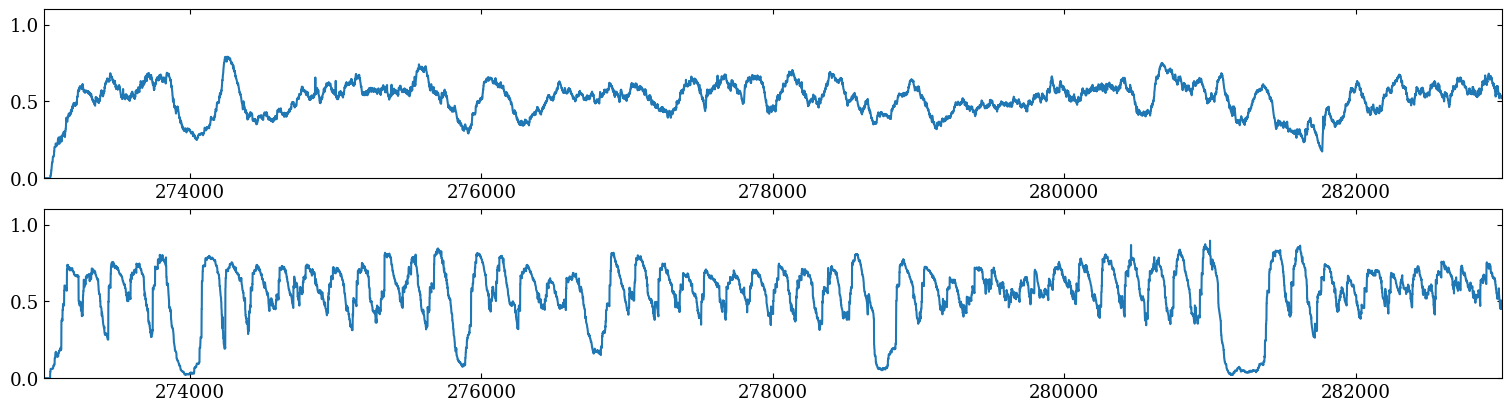

In [ ]:
read = reads_list[0]
print(read.is_reverse)
print(get_read_methylation_string(read, *locus))

read = next(r for r in reads_list if r.is_reverse)
print(read.is_reverse)
print(get_read_methylation_string(read, *locus))

trace_1 = np.zeros(end-start)
occupancy_1 = np.zeros(end - start)
trace_2 = np.zeros(end-start)
occupancy_2 = np.zeros(end - start)

for read in reads_list:
    if read.is_reverse:
        occupancy_1 += get_nucleosome_occupancy_meth(read, locus, length_limit=length_limit)
        meth_string = get_read_methylation_string(read, *locus)
        meth_string = meth_string[::-1]
        for idx, char in enumerate(meth_string):
                if char != '-':
                    trace_1[idx] += 1

    if not read.is_reverse:
        occupancy_2 += get_nucleosome_occupancy_meth(read, locus, length_limit=length_limit)
        meth_string = get_read_methylation_string(read, *locus)
        for idx, char in enumerate(meth_string):
                if char != '-':
                    trace_2[idx] += 1
    

occupancy_1 /= trace_1
occupancy_2 /= trace_2

x_coords = np.arange(start, end)

plotter = Plotter(fig_size = (15, 4))
plotter.new(ncols=1, nrows=2)

ax1, ax2 = plotter.axes

ax1.plot(x_coords, occupancy_1)
ax2.plot(x_coords, occupancy_2)
ax1.set_ylim(0, 1.1)
ax1.set_xlim(start, end)
ax2.set_ylim(0, 1.1)
ax2.set_xlim(start, end)

In [ ]:
print(len(read.seq))

28216
